In [2]:
!pip install ultralytics albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.4 MB/s eta 0:00:00a 0:00:01


In [3]:
import torch
from ultralytics import YOLO
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader
import os

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:

# Custom dataset class for loading images and applying Albumentations transformations
class YOLODataset(Dataset):
    def __init__(self, images_dir, labels_dir, transform=None):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        self.transform = transform
        self.image_paths = [os.path.join(images_dir, x) for x in os.listdir(images_dir)]
        self.label_paths = [os.path.join(labels_dir, x.replace(".jpg", ".txt")) for x in os.listdir(images_dir)]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        # Load image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load labels
        with open(label_path, 'r') as f:
            bboxes = []
            class_labels = []
            for line in f.readlines():
                class_id, x_center, y_center, width, height = map(float, line.strip().split())
                bboxes.append([x_center, y_center, width, height])
                class_labels.append(int(class_id))

        # Apply transformations
        if self.transform:
            transformed = self.transform(image=image, bboxes=bboxes, class_labels=class_labels)
            image = transformed['image']
            bboxes = transformed['bboxes']
            class_labels = transformed['class_labels']

        # Return image and labels
        return image, bboxes, class_labels

# Define the Albumentations transformation pipeline
transform = A.Compose([
    A.RandomCrop(width=1024, height=1024),
    A.Rotate(limit=10, p=0.5),
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Blur(p=0.1),
    A.CLAHE(p=0.1),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2, p=0.5),
    ToTensorV2()
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))


train_dataset = YOLODataset(
    images_dir='/kaggle/input/iiuc-idcard-data/train/images',
    labels_dir='/kaggle/input/iiuc-idcard-data/train/labels',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

model = YOLO("/kaggle/working/runs/detect/train2/weights/best.pt")

model.train(data="/kaggle/input/iiuc-idcard-data/data.yaml", epochs=300,batch=32, imgsz=640, lr0=0.000005,weight_decay=0.0005)

model.save("/kaggle/working/yolo_model_11m_v2.pt")

print("Training completed and model saved successfully.")


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/detect/train2/weights/best.pt'

GPU is available: Tesla T4
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/iiuc-idcard-data/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/yolov8s/pytorch/default/1/yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gpu_finetune5, nbs=64, nms=False, opset=None, optimi

NameError: name 'kaggle' is not defined

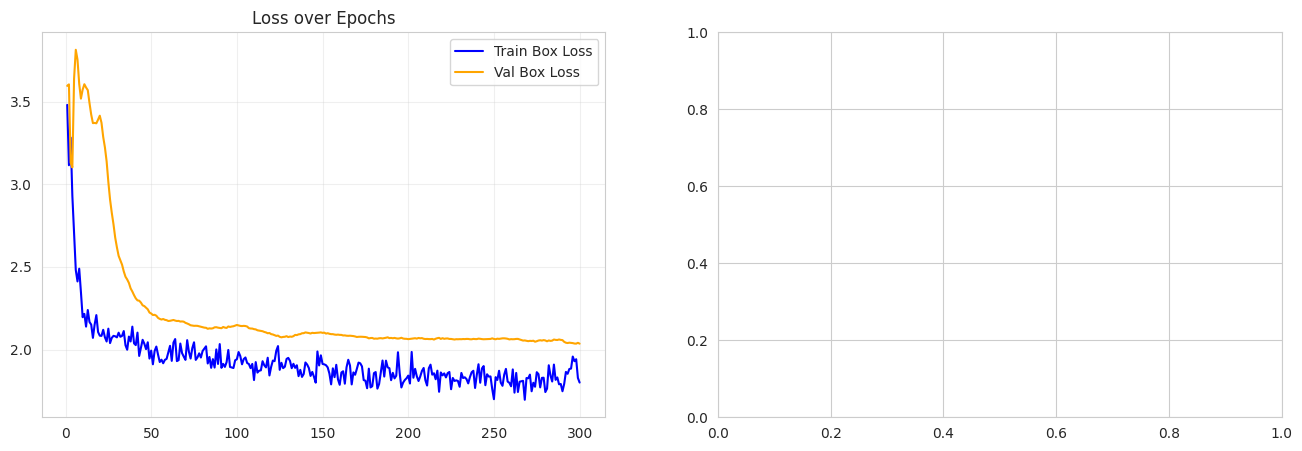

In [10]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display

# CHECK GPU AVAILABILITY
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    device_config = 0 # Use GPU 0
else:
    print("GPU not detected. Using CPU (Training will be slow).")
    device_config = 'cpu'

# 1. Load the Model
# Load previous best weights to continue fine-tuning
model = YOLO("/kaggle/input/yolov8s/pytorch/default/1/yolov8s.pt")

# 2. Train (Fine-Tuning)
# We map your previous Albumentations directly to YOLO hyperparameters here.
results = model.train(
    data="/kaggle/input/iiuc-idcard-data/data.yaml", # <--- Points to your dataset
    device=device_config,                             # <--- Enforce GPU usage
    
    epochs=300,
    batch=8,
    imgsz=1280,
    
    # Optimizer & Learning Rate
    lr0=1e-5,             # Small learning rate for fine-tuning
    lrf=0.01,
    optimizer='AdamW', 
    weight_decay=0.0005,
    
    # --- AUGMENTATION MAPPING ---
    # These arguments replace your manual Albumentations pipeline
    degrees=10.0,         # Rotates image +/- 10 degrees
    scale=0.2,            # Scales image +/- 20%
    fliplr=0.5,           # 50% chance of horizontal flip
    hsv_h=0.015,          # Adjust Hue (Color Jitter)
    hsv_s=0.2,            # Adjust Saturation (Color Jitter)
    hsv_v=0.2,            # Adjust Brightness/Value (Color Jitter)
    mosaic=1.0,           # Mosaic augmentation (combines 4 images)
    translate=0.1,        # Translation (shifting image)
    
    # Logging & Saving
    val=True,             # Validate on data.yaml 'val' set every epoch
    plots=True,           # Save plots (Loss, Confusion Matrix)
    save=True,            # Save checkpoints
    project='/kaggle/working/runs/detect',
    name='gpu_finetune'   # Run name
)

# 3. Final Validation
print("\n--- Running Final Validation ---")
# This automatically uses the 'val' path from your data.yaml
metrics = model.val(split='val')
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

# 4. Save
model.save("/kaggle/working/final_model_gpu.pt")

# --- PLOTTING HELPERS ---
def plot_results(run_dir):
    """Visually display the training progress from the CSV logs."""
    results_path = os.path.join(run_dir, 'results.csv')
    
    if os.path.exists(results_path):
        df = pd.read_csv(results_path)
        df.columns = [x.strip() for x in df.columns]

        fig, ax = plt.subplots(1, 2, figsize=(16, 5))
        
        # Loss Curves
        ax[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
        if 'val/box_loss' in df.columns:
            ax[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange')
        ax[0].set_title('Loss over Epochs')
        ax[0].legend()
        ax[0].grid(True, alpha=0.3)
        
        # mAP Curves
        ax[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
        ax[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='purple')
        ax[1].set_title('Precision (mAP) over Epochs')
        ax[1].legend()
        ax[1].grid(True, alpha=0.3)
        
        plt.show()

        # Show Validation Predictions
        val_img = os.path.join(run_dir, 'val_batch0_pred.jpg')
        if os.path.exists(val_img):
            print("Validation Batch Predictions:")
            display(Image(filename=val_img, width=800))
            
# Display plots
plot_results('/kaggle/working/runs/detect/gpu_finetune')

In [12]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display

# CHECK GPU AVAILABILITY
if torch.cuda.is_available():
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    device_config = 0 # Use GPU 0
else:
    print("GPU not detected. Using CPU (Training will be slow).")
    device_config = 'cpu'

# 1. Load the Model
# Load previous best weights to continue fine-tuning
model = YOLO("/kaggle/input/yolov8m/pytorch/default/1/yolov8m.pt")

# 2. Train (Fine-Tuning)
# We map your previous Albumentations directly to YOLO hyperparameters here.
results = model.train(
    data="/kaggle/input/iiuc-idcard-data/data.yaml", # <--- Points to your dataset
    device=device_config,                             # <--- Enforce GPU usage
    
    epochs=120,
    batch=32,
    imgsz=640,
    
    # Optimizer & Learning Rate
    lr0=1e-5,             # Small learning rate for fine-tuning
    lrf=0.01,
    optimizer='AdamW', 
    weight_decay=0.0005,
    
    # --- AUGMENTATION MAPPING ---
    # These arguments replace your manual Albumentations pipeline
    degrees=10.0,         # Rotates image +/- 10 degrees
    scale=0.2,            # Scales image +/- 20%
    fliplr=0.5,           # 50% chance of horizontal flip
    hsv_h=0.015,          # Adjust Hue (Color Jitter)
    hsv_s=0.2,            # Adjust Saturation (Color Jitter)
    hsv_v=0.2,            # Adjust Brightness/Value (Color Jitter)
    mosaic=1.0,           # Mosaic augmentation (combines 4 images)
    translate=0.1,        # Translation (shifting image)
    
    # Logging & Saving
    val=True,             # Validate on data.yaml 'val' set every epoch
    plots=True,           # Save plots (Loss, Confusion Matrix)
    save=True,            # Save checkpoints
    project='/kaggle/working/runs/detect',
    name='gpu_finetune'   # Run name
)

# 3. Final Validation
print("\n--- Running Final Validation ---")
# This automatically uses the 'val' path from your data.yaml
metrics = model.val(split='val')
print(f"mAP50: {metrics.box.map50}")
print(f"mAP50-95: {metrics.box.map}")

# 4. Save
model.save("/kaggle/working/yolov8m_output.pt")

# --- PLOTTING HELPERS ---
def plot_results(run_dir):
    """Visually display the training progress from the CSV logs."""
    results_path = os.path.join(run_dir, 'results.csv')
    
    if os.path.exists(results_path):
        df = pd.read_csv(results_path)
        df.columns = [x.strip() for x in df.columns]

        fig, ax = plt.subplots(1, 2, figsize=(16, 5))
        
        # Loss Curves
        ax[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss', color='blue')
        if 'val/box_loss' in df.columns:
            ax[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss', color='orange')
        ax[0].set_title('Loss over Epochs')
        ax[0].legend()
        ax[0].grid(True, alpha=0.3)
        
        # mAP Curves
        ax[1].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50', color='green')
        ax[1].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95', color='purple')
        ax[1].set_title('Precision (mAP) over Epochs')
        ax[1].legend()
        ax[1].grid(True, alpha=0.3)
        
        plt.show()

        # Show Validation Predictions
        val_img = os.path.join(run_dir, 'val_batch0_pred.jpg')
        if os.path.exists(val_img):
            print("Validation Batch Predictions:")
            display(Image(filename=val_img, width=800))
            
# Display plots
plot_results('/kaggle/working/runs/detect/gpu_finetune')

GPU is available: Tesla T4
Ultralytics 8.4.7 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/input/iiuc-idcard-data/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=120, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.2, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=1e-05, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/yolov8m/pytorch/default/1/yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gpu_finetune7, nbs=64, nms=False, opset=None, optimi

RuntimeError: DataLoader worker (pid(s) 729, 730, 731, 732) exited unexpectedly